In [37]:
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
from scipy.stats import gaussian_kde
import seaborn as sns

In [39]:
# Load best run data 
shy = np.loadtxt('lstmHybridModel_Run2_testresults.txt')

lim_inf = -1
lim_sup = 1.2

# Detrending the data
x = shy[:, 8] - np.nanmean(shy[:, 8])
y = shy[:, 7] - np.nanmean(shy[:, 7])

# Detrend (removing the trend)
#x = x - np.polyval(np.polyfit(np.arange(len(x)), x, 1), np.arange(len(x)))
#y = y - np.polyval(np.polyfit(np.arange(len(y)), y, 1), np.arange(len(y)))


In [41]:
# Linear Regression
x_with_intercept = sm.add_constant(x)  # Adds a constant (intercept) to the input
model = sm.OLS(y, x_with_intercept).fit()  # Perform linear regression
coeff = model.params
Y_md = coeff[1] * x + coeff[0]  # Linear model prediction: Y = mx + b

# Create values for prediction line (Ysp)
vv = np.linspace(lim_inf, lim_sup, len(y))  
Ysp = coeff[1] * vv + coeff[0]

# Removing NaN values
idx = np.isnan(x)
ub = np.where(idx == 0)[0]  # Indices where NaN is not present
xr = x[ub]
yr = y[ub]

# Correlation
r = np.corrcoef(xr, yr)[0, 1]

# RMSE
rmse_test = np.sqrt(np.mean((xr - yr) ** 2))

# Bias
bias = np.sum(yr - xr) / len(xr)

# MAD (Mean Absolute Deviation)
mad = np.nanmean(np.abs(x - y))

# Percentiles
sta_prc = np.percentile(x, np.arange(0, 101, 1))
shy_prc = np.percentile(y, np.arange(0, 101, 1))
# Plot (if you want to visualize)
# plt.plot(sta_prc, shy_prc, 'ob', MarkerFaceColor='b', LineWidth=1.5)

# Other statistics for model evaluation
mad_prc = np.nanmean(np.abs(shy_prc - sta_prc))
mad3rd = mad + mad_prc

# Print results (optional)
print(f'SLF: {round(coeff[1],3)}')
print(f'Correlation: {round(r,3)}')
print(f'RMSE: {round(rmse_test,3)}')
print(f'Bias: {round(bias,3)}')
print(f'MAD: {round(mad,3)}')
print(f'MADp: {round(mad_prc,3)}')
print(f'MADc: {round(mad3rd,3)}')


SLF: 0.858
Correlation: 0.825
RMSE: 0.079
Bias: -0.0
MAD: 0.064
MADp: 0.008
MADc: 0.072


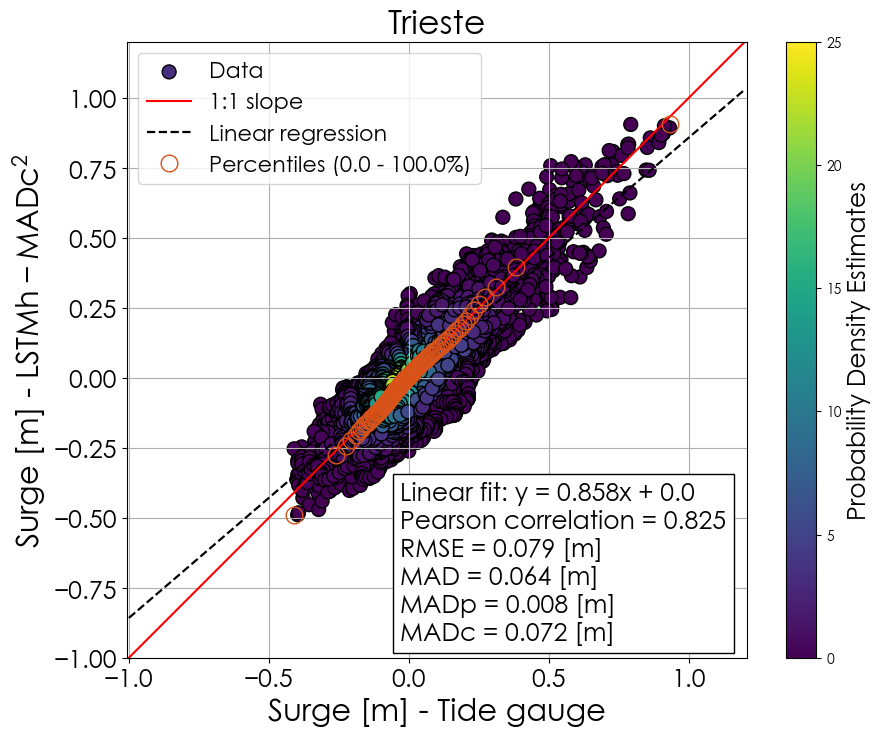

In [43]:
# Density scatter

# Calculate the point density
xy = np.vstack([xr, yr])
z = gaussian_kde(xy)(xy)

plt.rcParams['font.family'] = 'Century Gothic'  # Replace with your preferred font
# Ensure MathText uses the same font
plt.rcParams['mathtext.default'] = 'rm'  # Use the regular font for MathText
plt.rcParams['mathtext.fontset'] = 'custom'  # Enable custom font for MathText
plt.rcParams['mathtext.rm'] = 'Century Gothic'  # Set Roman font for MathText

# For plots
target = 'Tide gauge'
ml_method = r'$\mathrm{LSTMh-MADc}^2$'
#ml_method = 'MLR-MSE'

# Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(xr, yr, c=z, cmap='viridis', s=100, edgecolor='k', vmin=0, vmax=25)

# Plot the 1:1 line
ax.plot([lim_inf, lim_sup], [lim_inf, lim_sup], 'r', linewidth=1.5)

# Plot the linear regression line
ax.plot(np.linspace(lim_inf, lim_sup, len(x)), Ysp, '--k', linewidth=1.6)

# Percentiles 
ax.plot(sta_prc, shy_prc, 'o', color='#D95319', linewidth=2, markersize=12, markerfacecolor='none')

# Set labels and titles
ax.set_xlabel(f'Surge [m] - {target}', fontsize=22)
plt.ylabel(f'Surge [m] - {ml_method}', fontsize=22)
ax.set_title('Trieste', fontsize=24)
plt.legend(['Data', '1:1 slope', 'Linear regression', 'Percentiles (0.0 - 100.0%)'], loc='upper left', fontsize=16)

# Set limits and grid
plt.axis('equal')
ax.set_xlim(lim_inf, lim_sup)
ax.set_ylim(lim_inf, lim_sup)
ax.grid(True)

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Probability Density Estimates', fontsize=18)

# Customize ticks
ax.tick_params(axis='both', labelsize=18)

# Annotate the plot with statistical details
stats_text = [
    f'Linear fit: y = {round(coeff[1], 3)}x + {round(coeff[0], 5)}',
    f'Pearson correlation = {round(r, 3)}',
    f'RMSE = {round(rmse_test, 3)} [m]',
    f'MAD = {round(mad, 3)} [m]',
    f'MADp = {round(mad_prc, 3)} [m]',
    f'MADc = {round(mad3rd, 3)} [m]'
]
plt.annotate('\n'.join(stats_text), xy=(0.4, 0.12), xycoords='figure fraction', fontsize=18,
             bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.3'))

# Ensure the axes background is transparent
#ax.set_facecolor('none')

# Set the figure background to be white (outside the plot area)
#fig.patch.set_facecolor('w')

# Clean the method name for the filename
ml_method_clean = (
    ml_method.replace('$', '')  # Remove LaTeX math symbols
    .replace(r'\mathrm{', '')  # Remove the \mathrm{...}
    .replace('}', '')          # Remove closing braces
    .replace('{', '')          # Remove opening braces
    .replace('^', '')          # Remove caret for superscripts
    .replace('-', '_')         # Replace dash with underscore
)

# Generate the filename
filename = f'DS_targetTG_Trieste_{ml_method_clean}.png'

# Show the plot
#plt.show()

# Save the figure with transparent axes but white background
plt.savefig(filename, dpi=300, bbox_inches='tight')
